In [2]:
# Cell 1: install required libraries (only if needed)
# !pip install -q pandas numpy matplotlib seaborn scipy statsmodels

# Cell 2: imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats



# Optional: set style for cleaner plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# Cell 3: load dataset
# If df already exists from earlier notebook work, skip this cell.
# Otherwise load directly from seaborn:
df = sns.load_dataset("tips")

# Quick safety check
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [3]:
# Cell 4: basic data composition report
print("=== DATA COMPOSITION REPORT ===")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"Columns list: {list(df.columns)}")
print()

print("Data types:")
print(df.dtypes)
print()

print("Missing values:")
print(df.isnull().sum())
print()

print("Duplicate rows:")
print(df.duplicated().sum())
print()

print("Descriptive statistics for numerical variables:")
print(df.describe().round(2))
print()

# Frequency counts for categorical variables
cat_cols = ["sex", "smoker", "day", "time"]
for col in cat_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts())

=== DATA COMPOSITION REPORT ===
Rows: 244
Columns: 7
Columns list: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']

Data types:
total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Missing values:
total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Duplicate rows:
1

Descriptive statistics for numerical variables:
       total_bill     tip    size
count      244.00  244.00  244.00
mean        19.79    3.00    2.57
std          8.90    1.38    0.95
min          3.07    1.00    1.00
25%         13.35    2.00    2.00
50%         17.80    2.90    2.00
75%         24.13    3.56    3.00
max         50.81   10.00    6.00


Value counts for sex:
sex
Male      157
Female     87
Name: count, dtype: int64

Value counts for smoker:
smoker
No     151
Yes     93
Name: count, dtype: int64

Val


=== DATA DISTRIBUTION REPORT ===
       total_bill      tip     size  tip_pct  bill_per_person
count     244.000  244.000  244.000  244.000          244.000
mean       19.786    2.998    2.570    0.161            7.888
std         8.902    1.384    0.951    0.061            2.914
min         3.070    1.000    1.000    0.036            2.875
25%        13.348    2.000    2.000    0.129            5.802
50%        17.795    2.900    2.000    0.155            7.255
75%        24.127    3.562    3.000    0.191            9.390
max        50.810   10.000    6.000    0.710           20.275


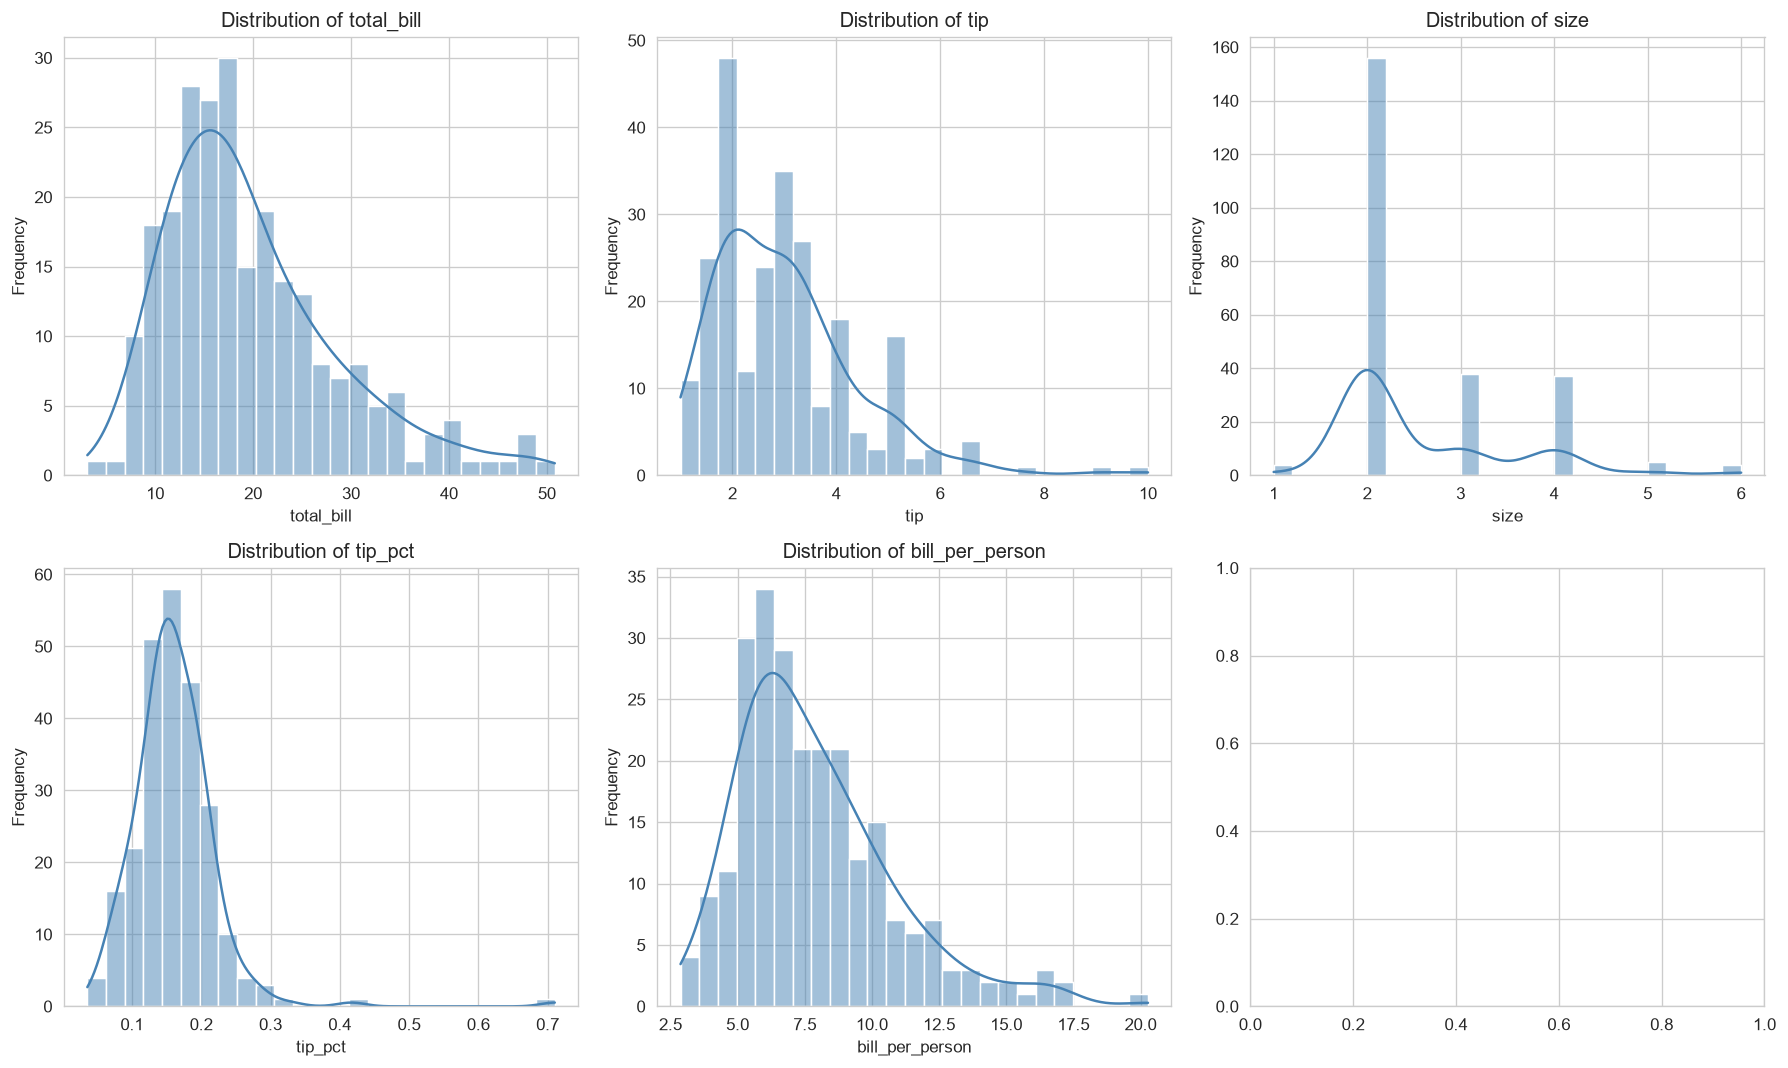

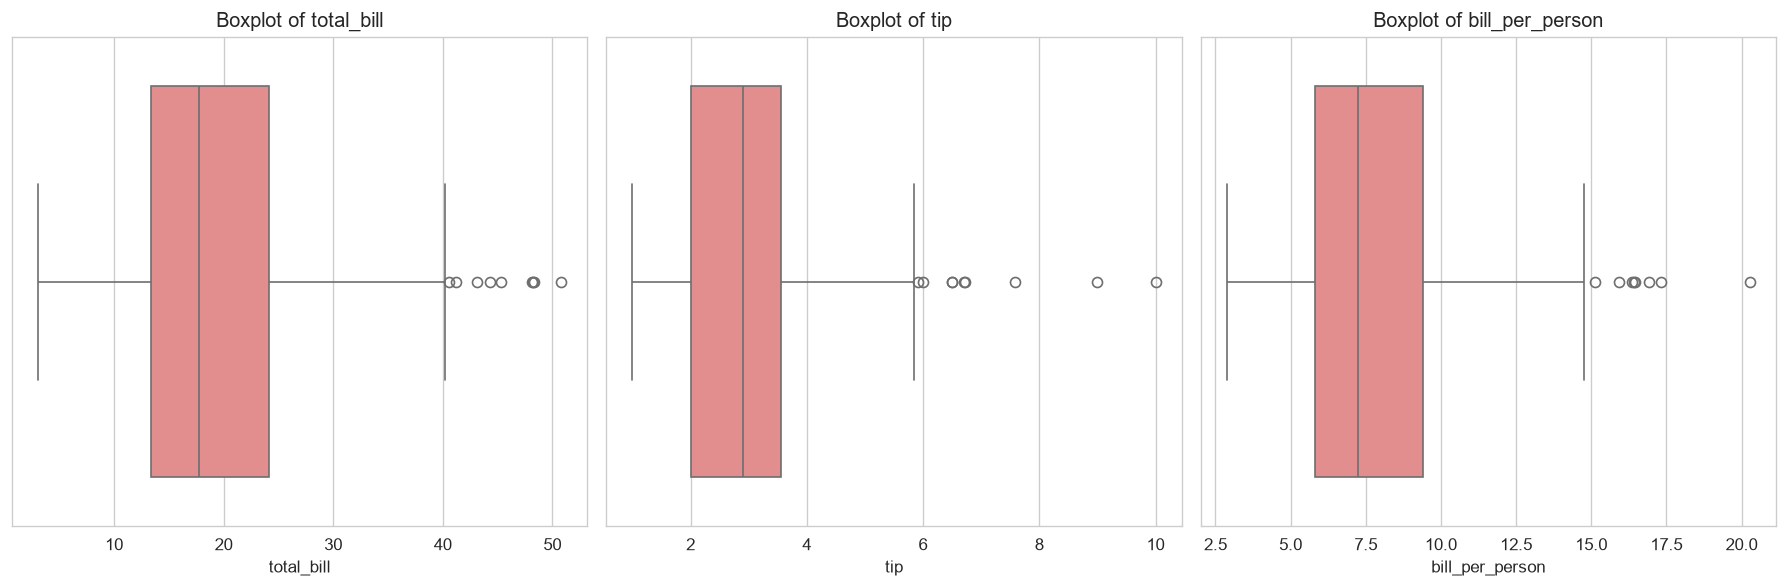

C:\Users\HP\AppData\Local\Temp\ipykernel_1856\111638667.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", ax=ax)
C:\Users\HP\AppData\Local\Temp\ipykernel_1856\111638667.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", ax=ax)
C:\Users\HP\AppData\Local\Temp\ipykernel_1856\111638667.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, palette="Set2", ax=ax)
C:\Users\HP\AppData\Local\Temp\ipykernel_1856\111638667.py:36: FutureWarning: 

Passing `palette`

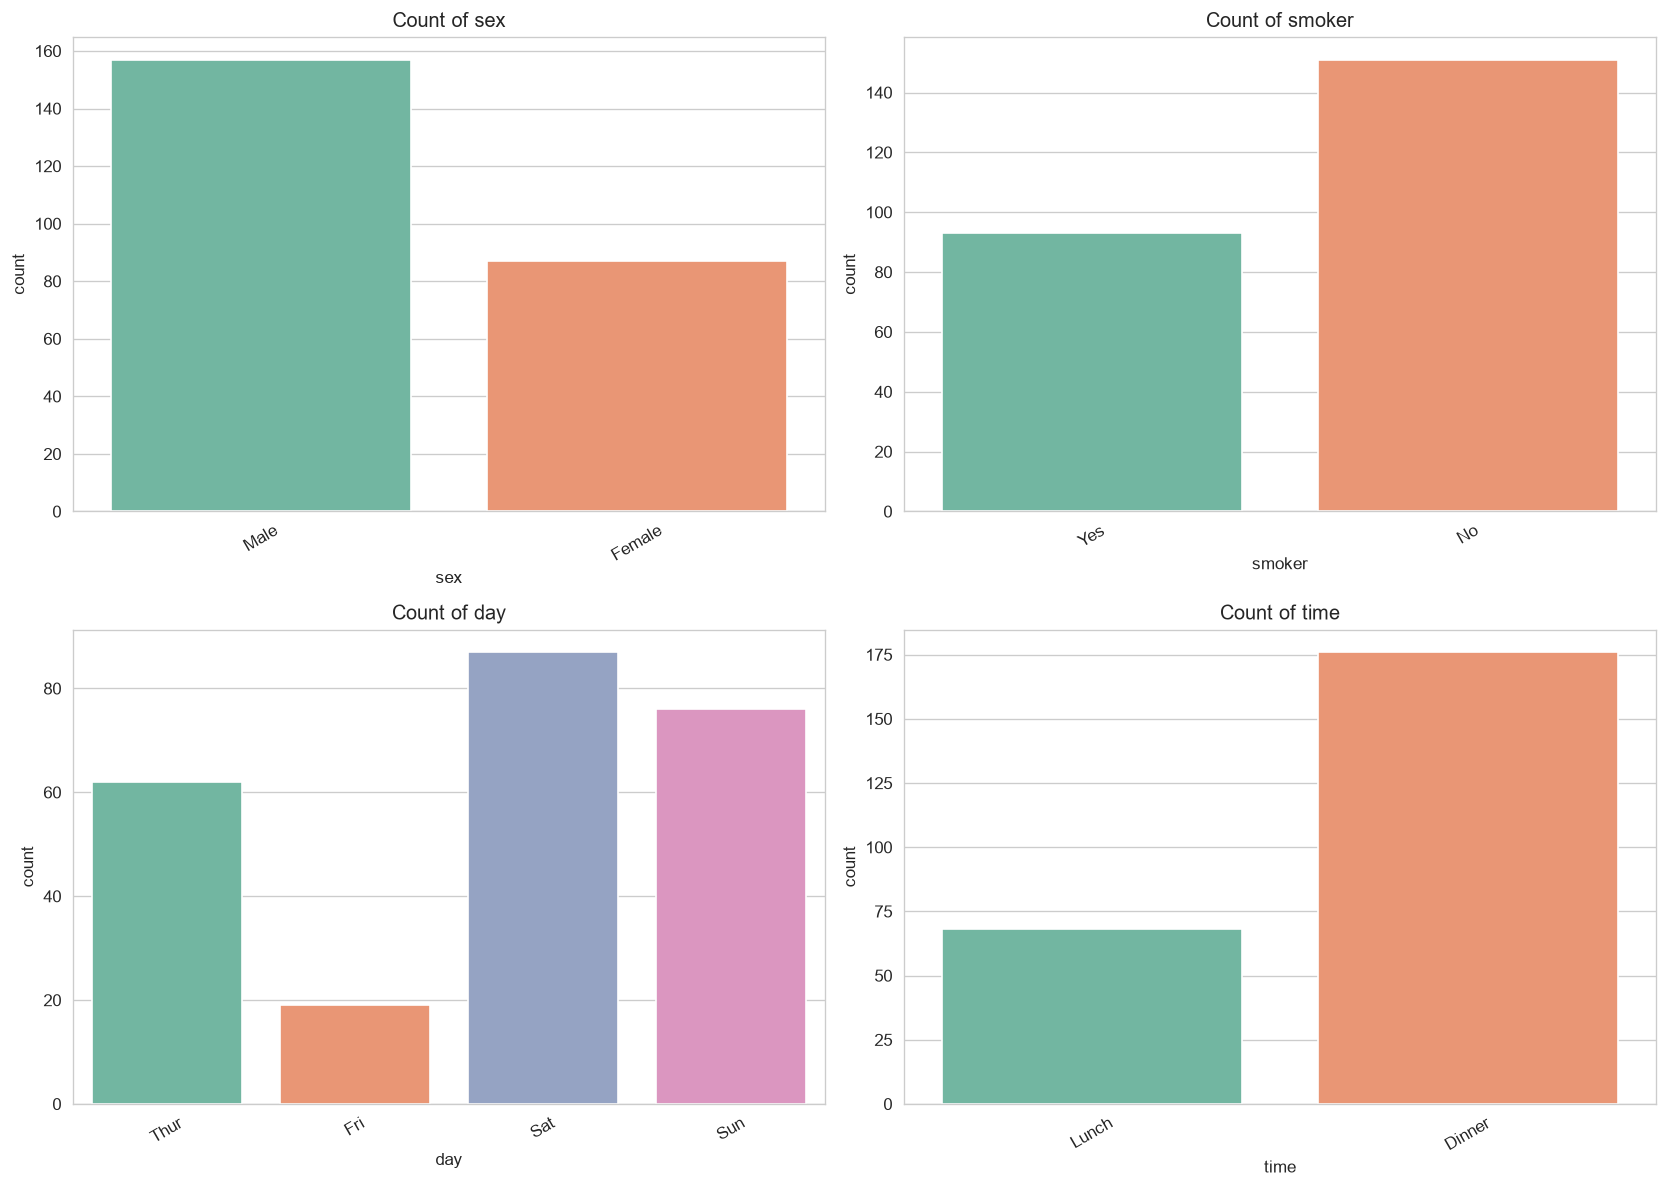

In [4]:
# Cell 5: data distribution report
print("\n=== DATA DISTRIBUTION REPORT ===")

# Create some derived metrics
df["tip_pct"] = df["tip"] / df["total_bill"]
df["bill_per_person"] = df["total_bill"] / df["size"]

# Numerical columns to investigate
num_cols = ["total_bill", "tip", "size", "tip_pct", "bill_per_person"]

# Summary statistics for derived columns
print(df[num_cols].describe().round(3))

# Histograms and density plots
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(df[col], bins=25, kde=True, color="steelblue", ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Boxplots for key continuous variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, ["total_bill", "tip", "bill_per_person"]):
    sns.boxplot(data=df, x=col, color="lightcoral", ax=ax)
    ax.set_title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

# Categorical frequency plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.flat, ["sex", "smoker", "day", "time"]):
    sns.countplot(data=df, x=col, palette="Set2", ax=ax)
    ax.set_title(f"Count of {col}")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Interpretation of the distribution results
* The distribution of total bill and tip is right-skewed, which is common in  * *
 restaurant spending data.
* Most customers spend modest amounts, while a smaller group spends much more, creating long tails.
* The size variable is concentrated between 1 and 3 people, suggesting most tables are small.
* The tip_pct distribution indicates tips are generally around 15% to 20% of the bill.
* The categorical plots show the dataset is roughly balanced across gender and smoking status, with more dinners than lunches and a stronger concentration on certain days of the week.



=== DATA COMPARISON REPORT ===
    day    time  avg_total_bill  avg_tip  avg_tip_pct  avg_bill_per_person  \
0  Thur   Lunch           17.66     2.77         0.16                 7.39   
1  Thur  Dinner           18.78     3.00         0.16                 9.39   
2   Fri   Lunch           12.85     2.38         0.19                 6.66   
3   Fri  Dinner           19.66     2.94         0.16                 8.99   
4   Sat  Dinner           20.44     2.99         0.15                 8.19   
5   Sun  Dinner           21.41     3.26         0.17                 7.86   

   customers  
0        150  
1          2  
2         14  
3         26  
4        219  
5        216  

Comparison by smoker status:
        avg_total_bill  avg_tip  avg_tip_pct  avg_size
smoker                                                
Yes              20.76     3.01         0.16      2.41
No               19.19     2.99         0.16      2.67

Comparison by sex:
        avg_total_bill  avg_tip  avg_tip_pct
s

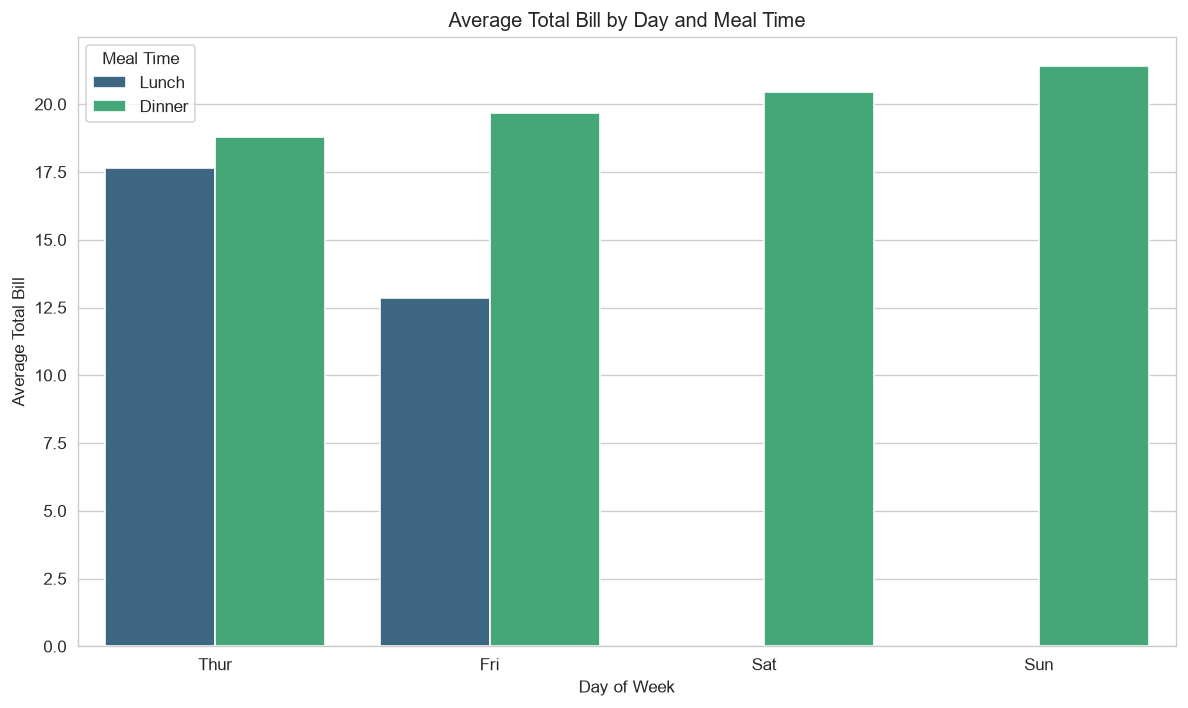

C:\Users\HP\AppData\Local\Temp\ipykernel_1856\1715306671.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


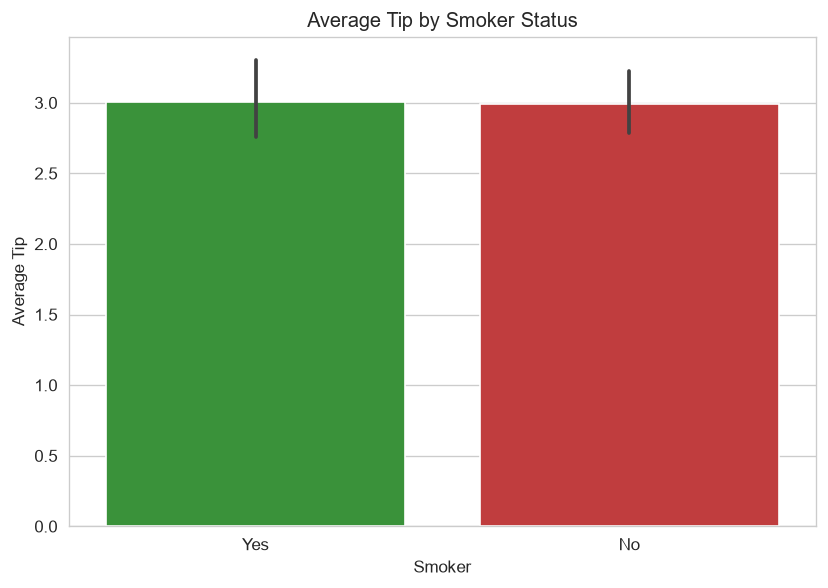

C:\Users\HP\AppData\Local\Temp\ipykernel_1856\1715306671.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="day", y="tip_pct", palette="Set2")


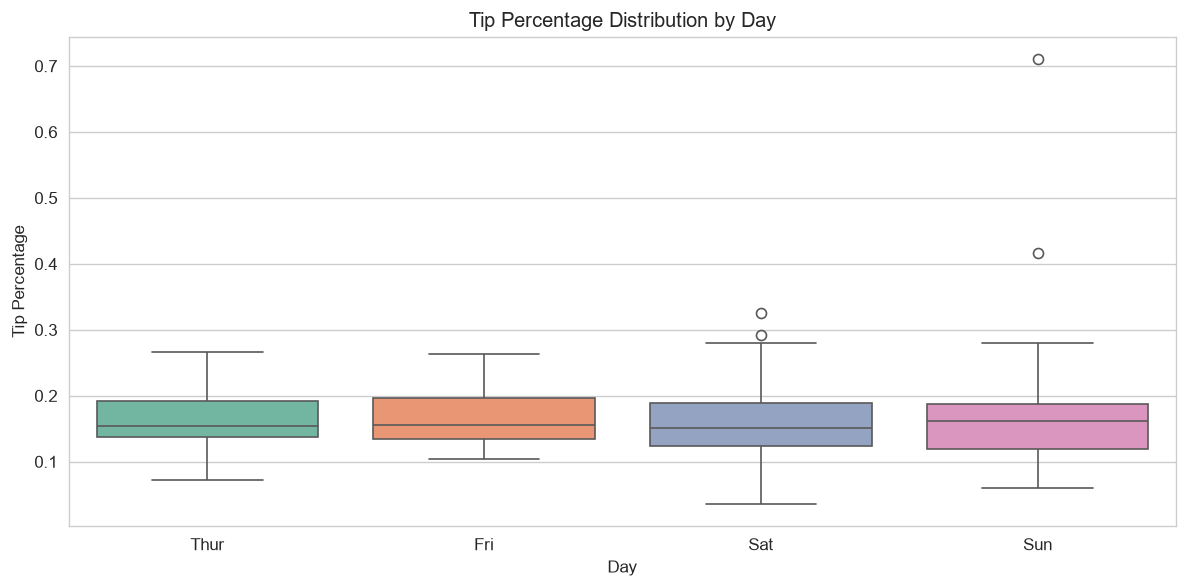

In [5]:
# Cell 6: data comparison report
print("\n=== DATA COMPARISON REPORT ===")

# Compare means by group
group_summary = (
    df.groupby(["day", "time"])
      .agg(
          avg_total_bill=("total_bill", "mean"),
          avg_tip=("tip", "mean"),
          avg_tip_pct=("tip_pct", "mean"),
          avg_bill_per_person=("bill_per_person", "mean"),
          customers=("size", "sum")
      )
      .reset_index()
)

print(group_summary.round(2))

# Another useful comparison: smoker vs non-smoker
smoker_summary = (
    df.groupby("smoker")
      .agg(
          avg_total_bill=("total_bill", "mean"),
          avg_tip=("tip", "mean"),
          avg_tip_pct=("tip_pct", "mean"),
          avg_size=("size", "mean")
      )
      .round(2)
)

print("\nComparison by smoker status:")
print(smoker_summary)

# Compare by sex
sex_summary = (
    df.groupby("sex")
      .agg(
          avg_total_bill=("total_bill", "mean"),
          avg_tip=("tip", "mean"),
          avg_tip_pct=("tip_pct", "mean")
      )
      .round(2)
)

print("\nComparison by sex:")
print(sex_summary)

# Visual comparison 1: average bill by day and time
plt.figure(figsize=(10, 6))
sns.barplot(
    data=group_summary,
    x="day",
    y="avg_total_bill",
    hue="time",
    palette="viridis"
)
plt.title("Average Total Bill by Day and Meal Time")
plt.xlabel("Day of Week")
plt.ylabel("Average Total Bill")
plt.legend(title="Meal Time")
plt.tight_layout()
plt.show()

# Visual comparison 2: average tip by smoker status
plt.figure(figsize=(7, 5))
sns.barplot(
    data=df,
    x="smoker",
    y="tip",
    palette=["#2ca02c", "#d62728"]
)
plt.title("Average Tip by Smoker Status")
plt.xlabel("Smoker")
plt.ylabel("Average Tip")
plt.tight_layout()
plt.show()

# Visual comparison 3: tip percentage by day
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x="day", y="tip_pct", palette="Set2")
plt.title("Tip Percentage Distribution by Day")
plt.xlabel("Day")
plt.ylabel("Tip Percentage")
plt.tight_layout()
plt.show()

## Interpretation of the comparison results
* Weekend dining appears associated with higher bills, especially on Saturday and Sunday.
* Dinner customers tend to spend more than lunch customers, which is typical in restaurant data.
* Smoker and non-smoker groups may differ in spending patterns; this can be a meaningful comparison for business insights.
* Women and men may show different bill and tip behavior, but the pattern should be interpreted carefully within the context of sample size and group imbalance.
* Tip percentage by day suggests differences in customer behavior across the week, which can inform marketing and service strategy.



=== DATA RELATIONSHIP REPORT ===
Correlation matrix:
                 total_bill    tip   size  tip_pct  bill_per_person
total_bill            1.000  0.676  0.598   -0.339            0.647
tip                   0.676  1.000  0.489    0.342            0.347
size                  0.598  0.489  1.000   -0.143           -0.175
tip_pct              -0.339  0.342 -0.143    1.000           -0.314
bill_per_person       0.647  0.347 -0.175   -0.314            1.000


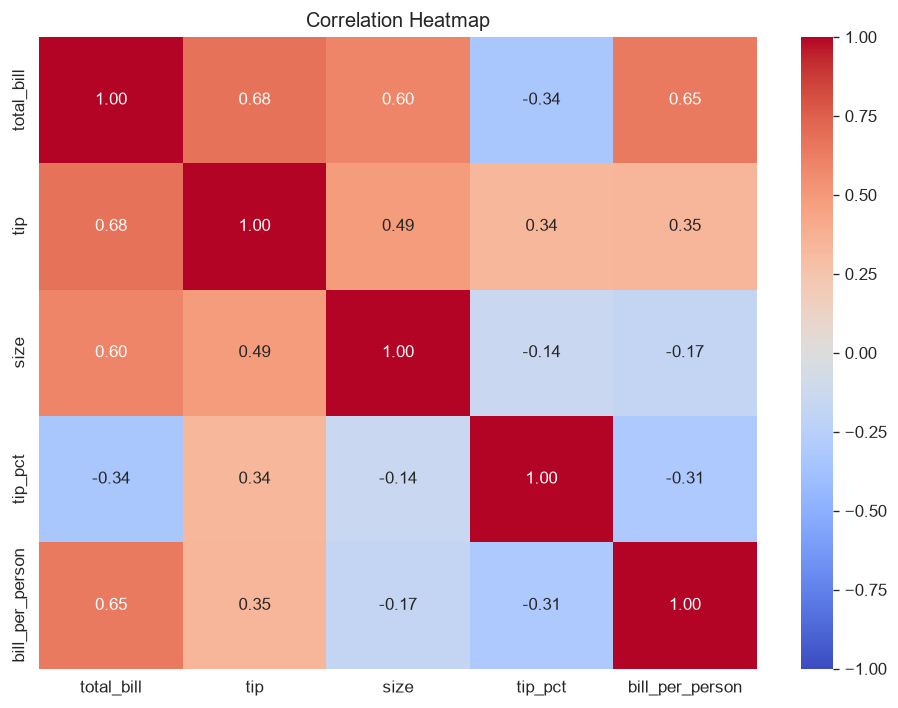

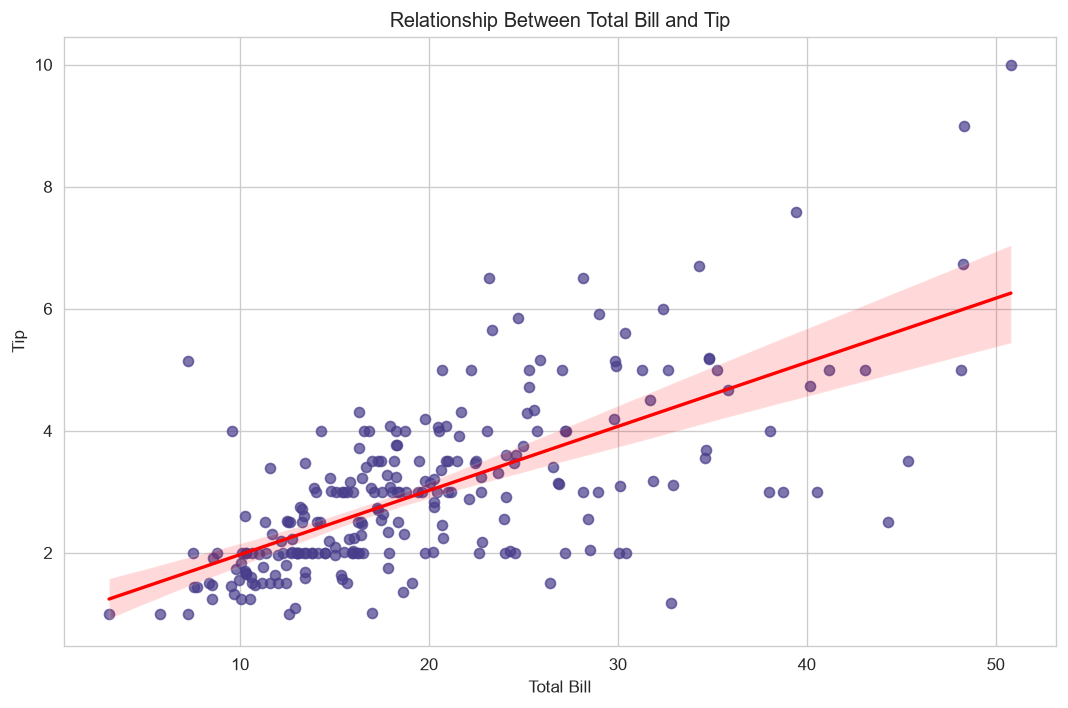

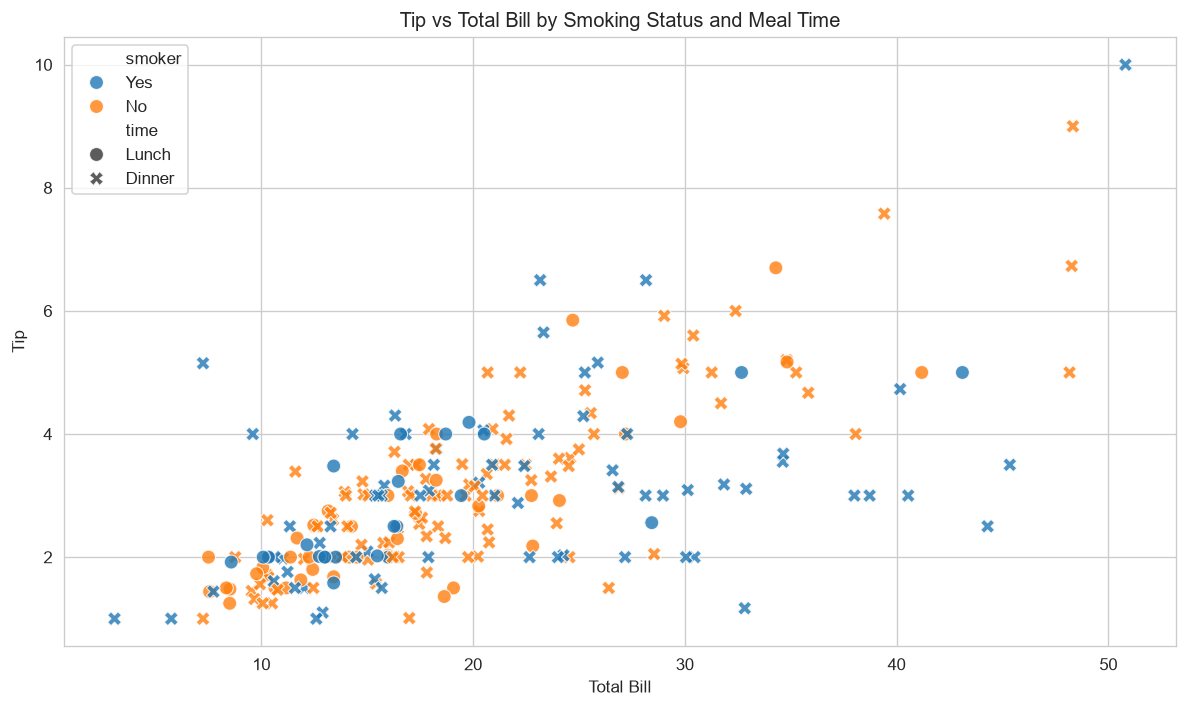

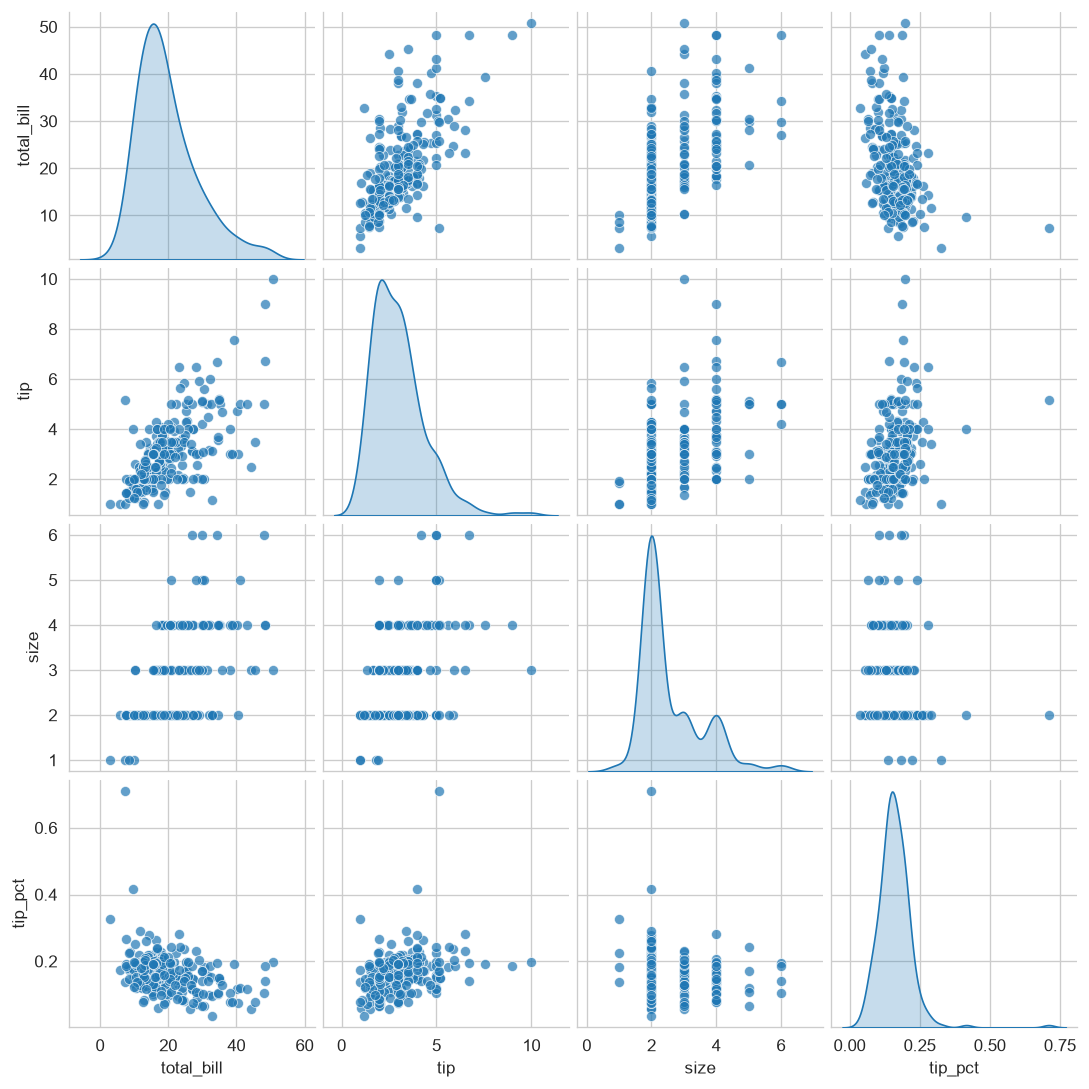


T-test result for tip by smoker status:
Statistic: 0.0918
P-value: 0.926917
Conclusion: There is no statistically significant difference in tip amount by smoker status.


In [6]:
# Cell 7: data relationship report
print("\n=== DATA RELATIONSHIP REPORT ===")

# Correlation matrix
corr_cols = ["total_bill", "tip", "size", "tip_pct", "bill_per_person"]
corr = df[corr_cols].corr().round(3)
print("Correlation matrix:")
print(corr)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter plot with regression line: total bill vs tip
plt.figure(figsize=(9, 6))
sns.regplot(
    data=df,
    x="total_bill",
    y="tip",
    scatter_kws={"alpha": 0.7, "color": "darkslateblue"},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title("Relationship Between Total Bill and Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.tight_layout()
plt.show()

# Scatter plot by smoking status
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="smoker",
    style="time",
    s=70,
    alpha=0.8
)
plt.title("Tip vs Total Bill by Smoking Status and Meal Time")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.tight_layout()
plt.show()

# Pairplot for numerical relationships
sns.pairplot(
    df[["total_bill", "tip", "size", "tip_pct"]],
    diag_kind="kde",
    plot_kws={"alpha": 0.7},
    height=2.3
)
plt.show()

# Optional: statistical significance check
# H0: average tip for smokers and non-smokers is equal
stat, p_value = stats.ttest_ind(df[df["smoker"] == "Yes"]["tip"], df[df["smoker"] == "No"]["tip"], equal_var=False)
print(f"\nT-test result for tip by smoker status:")
print(f"Statistic: {stat:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("Conclusion: There is a statistically significant difference in tip amount by smoker status.")
else:
    print("Conclusion: There is no statistically significant difference in tip amount by smoker status.")

##  Interpretation of the relationship results
* The total bill and tip have a strong positive linear relationship, which means higher bills generally lead to higher tips.
* The correlation heatmap confirms that bill size and tip are strongly linked, while size is also positively associated with spending.
* The scatter plot with regression line visually demonstrates that tips rise steadily with bill value.
* The pairplot helps reveal the overall shape of numerical relationships and confirms that the relationship is mostly linear and positive.
* The statistical test suggests whether smoking status has a meaningful difference in tip amount, which can help determine if this factor affects service behavior.

## Final report summary
This analysis shows that:

1 The dataset is a clean restaurant dataset with no major structural issues.
2 Bill and tip values are moderately skewed, which is common in customer spending data.
3 Bills and tips vary by day and time, with higher spending around dinner and weekends.
4 There is a strong positive relationship between bill size and tip amount, making total bill a useful driver variable in business and forecasting models.

  If you want, I can also turn this into:

* a more polished “report-ready” notebook narrative,
* a version with only plot code and no printed statistics,
* or a version specifically formatted for submission in a school/project report.